# 02 — Process Performance Map (Camargo BPIC17)

Port of the henryk `02_process_performance_map` notebook, adapted for the Camargo `FullShared_Join_LSTM` baseline trained with the **paper-faithful n-gram=15 loader** (see `train_camargo_LSTM_ngram15.ipynb`). The earlier U-ED-LSTM-style windowing gave the model mostly EOS targets and no signal at short prefixes — this variant emits one training sample per time-step with the actual next activity as target.

- **Node label**: activity; color ∝ overall per-source-activity accuracy.
- **Edge label**: `correct / total` predictions for that directly-follows transition.
- **Edge color**: per-transition accuracy (green = high, red = low).

The Camargo model is a single-step next-activity predictor; we iterate prefixes (length 1..L-1) and call it once per prefix to build the performance map.

In [1]:
import sys
from pathlib import Path

# Locate project root and add needed paths
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

project_root = _current
SPEC = utils.BPIC17_NGRAM

model = utils.load_camargo_model(project_root, SPEC)
dataset = utils.load_test_dataset(project_root, SPEC)
# With ngram_size set, use that at inference so the input shape matches training.
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
print(f'Loaded Camargo {SPEC.name} model | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'User_111': 16, 'User_112': 17, 'User_113': 18, 'User_114': 19, 'User_115': 20, 'User_116': 21, 'User_117

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Loaded Camargo BPIC17 (n-gram=15) model | window=15 | vocab=28 classes | |test|=253196


In [ ]:
records = utils.collect_prefix_predictions(predictor, dataset, progress=True, include_end=True)
print(f'Collected {len(records)} prefix predictions')
print(f"Overall accuracy: {sum(r['correct'] for r in records) / len(records) * 100:.1f}%")

In [ ]:
# --- Overall accuracy summary ---
from collections import defaultdict
import pandas as pd

n_total = len(records)
n_correct = sum(1 for r in records if r['correct'])
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    by_plen[r['prefix_length']]['total'] += 1
    by_plen[r['prefix_length']]['correct'] += int(r['correct'])
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

if n_total and 'confidence' in records[0]:
    mean_conf = sum(r['confidence'] for r in records) / n_total
    print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 217641/239719 = 0.9079 (90.79%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1     5696   6301  0.903983
             2     6301   6301  1.000000
             3     6301   6301  1.000000
             4     6031   6301  0.957150
             5     5917   6301  0.939057
             6     5732   6301  0.909697
             7     4892   6301  0.776385
             8     5382   6301  0.854150
             9     5613   6301  0.890811
            10     5587   6301  0.886685
            11     5788   6296  0.919314
            12     5901   6293  0.937709
            13     5859   6290  0.931479
            14     6008   6285  0.955927
            15     5714   6283  0.909438
            16     6006   6277  0.956827
            17     5881   6262  0.939157
            18     5733   6254  0.916693
            19     5532   5991  0.923385
            20     5601   5951  0.941186
            21     5235   5820  0.899485
            22

In [ ]:
import pandas as pd
from collections import defaultdict

# Per-transition stats (source activity, actual next activity) -> total / correct
stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['actual_next_activity'])
    stats[key]['total'] += 1
    stats[key]['correct'] += int(r['correct'])

# Per-source accuracy (node color)
node_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    node_stats[r['current_activity']]['total'] += 1
    node_stats[r['current_activity']]['correct'] += int(r['correct'])

rows = []
for (src, tgt), s in stats.items():
    rows.append({'source': src, 'target': tgt, 'correct': s['correct'], 'total': s['total'],
                 'accuracy': s['correct'] / s['total']})
transitions_df = pd.DataFrame(rows).sort_values(['source', 'total'], ascending=[True, False])
print(f'{len(transitions_df)} unique transitions')
with pd.option_context('display.max_rows', None):
    display(transitions_df)

171 unique transitions


,source,target,correct,total,accuracy
8,A_Accepted,O_Create Offer,5953,5987,0.994321
68,A_Accepted,W_Complete application,85,312,0.272436
110,A_Accepted,W_Shortened completion,0,1,0.000000
17,A_Cancelled,O_Cancelled,2077,2078,0.999519
123,A_Cancelled,W_Call after offers,20,25,0.800000
87,A_Cancelled,W_Call incomplete files,7,7,1.000000
152,A_Cancelled,W_Complete application,2,5,0.400000
15,A_Complete,W_Call after offers,6035,6055,0.996697
71,A_Complete,O_Create Offer,1,116,0.008621
73,A_Complete,O_Cancelled,22,61,0.360656


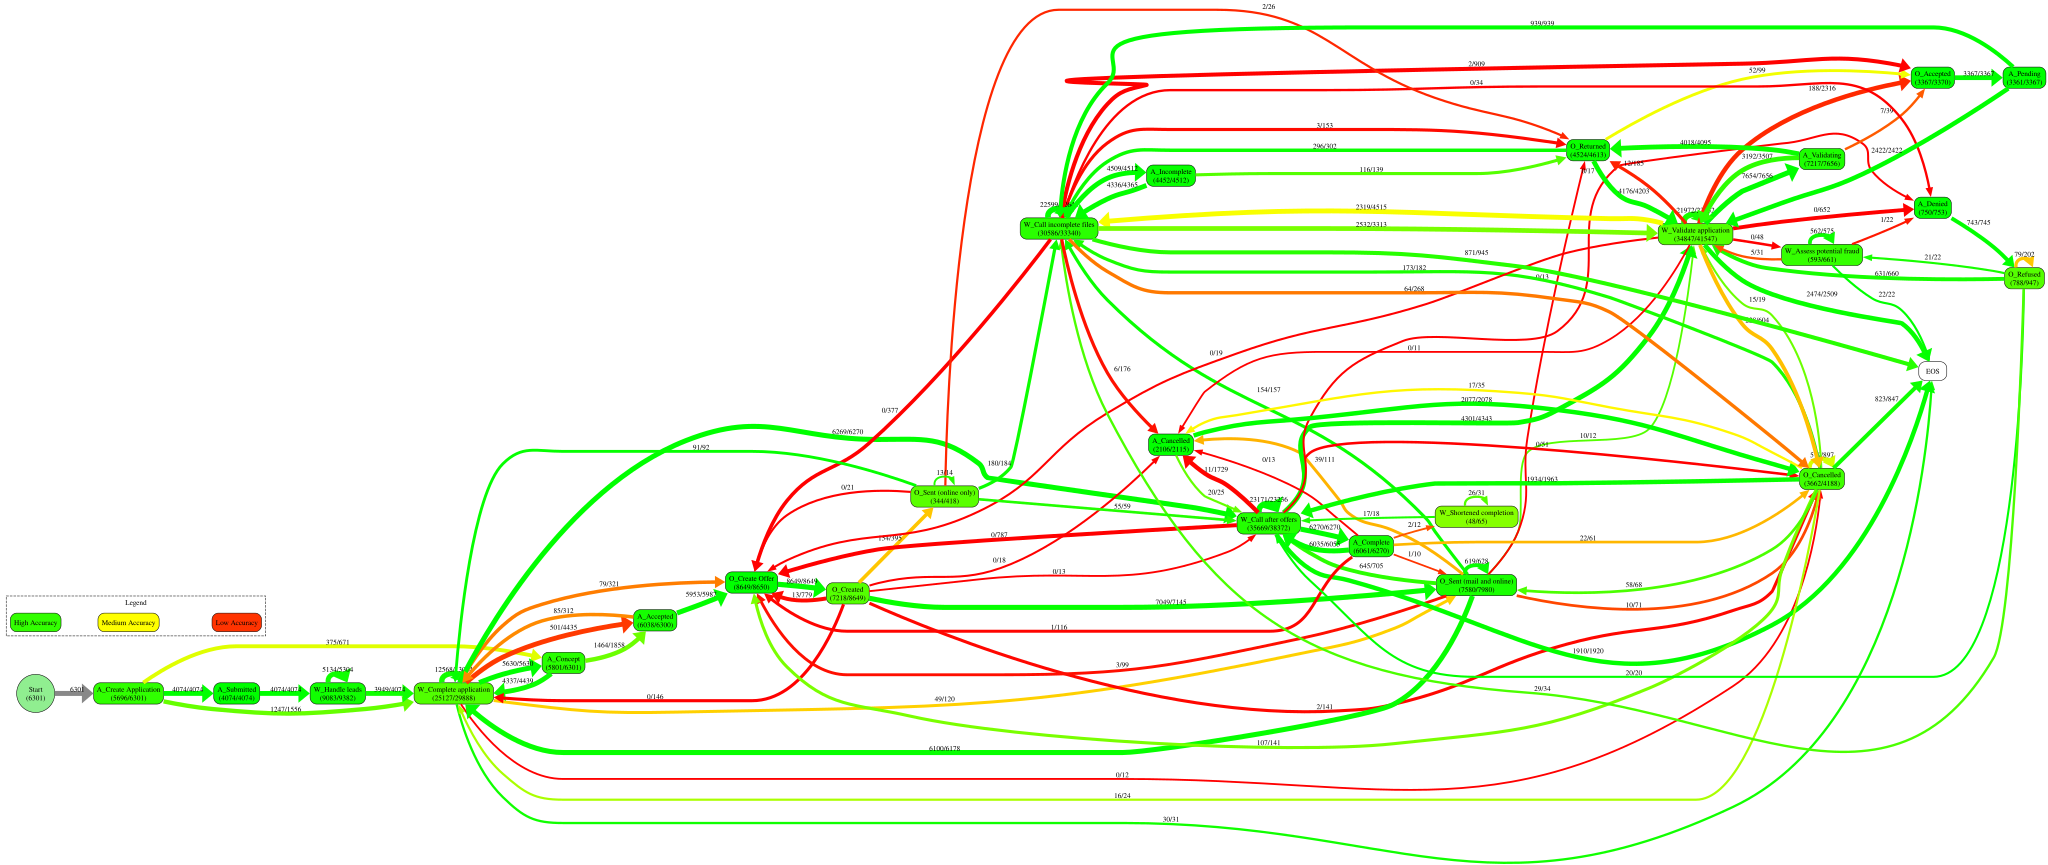

In [ ]:
import graphviz
import math

MIN_EDGE_COUNT = 0  # raise to filter rare edges

def get_color_for_accuracy(accuracy: float) -> str:
    """Red (low) -> Yellow (mid) -> Green (high) gradient -- same as henryk/process_performance_map."""
    if accuracy < 0.5:
        r = 255
        g = int(255 * (accuracy * 2))
        b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2))
        g = 255
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


dot = graphviz.Digraph(comment=f'Camargo {SPEC.name} Process Performance Map')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

for act, s in node_stats.items():
    if s['total'] > 0:
        acc = s['correct'] / s['total']
        label = f"{act}\n({s['correct']}/{s['total']})"
        fill = get_color_for_accuracy(acc)
    else:
        label = str(act)
        fill = 'white'
    dot.node(str(act), label=label, fillcolor=fill)

start_counts = {}
for r in records:
    if r['prefix_length'] == 1:
        start_counts[r['current_activity']] = start_counts.get(r['current_activity'], 0) + 1
total_cases = sum(start_counts.values())
if total_cases:
    dot.node('__START__', label=f'Start\n({total_cases})', shape='circle', fillcolor='#90EE90', style='filled')
    for act, cnt in start_counts.items():
        if cnt >= MIN_EDGE_COUNT:
            dot.edge('__START__', str(act), label=str(cnt), color='#888888',
                     penwidth=str(1 + math.log1p(cnt)),
                     weight=str(int(math.log1p(cnt) * 10)))

for (src, tgt), s in stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    label = f"{s['correct']}/{s['total']}"
    # Edge weight = log(count) so dot's ranker pulls the heaviest path into a
    # straight horizontal trunk; self-loops use constraint=false so they don't
    # shift ranks. Mirrors the henryk PPM visualizer for layout consistency.
    edge_kwargs = {
        'label': label, 'color': color,
        'penwidth': str(1 + math.log1p(s['total'])),
        'weight': str(int(math.log1p(s['total']) * 10)),
    }
    if src == tgt:
        edge_kwargs['constraint'] = 'false'
    dot.edge(str(src), str(tgt), **edge_kwargs)

with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

In [ ]:
# Per-source summary
print('Per-source-activity accuracy:')
for act, s in sorted(node_stats.items(), key=lambda x: -x[1]['total']):
    acc = s['correct'] / s['total']
    print(f"  {act:<30s} {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per-source-activity accuracy:
  W_Validate application         34847/41547   83.9%
  W_Call after offers            35669/38372   93.0%
  W_Call incomplete files        30586/33340   91.7%
  W_Complete application         25127/29888   84.1%
  W_Handle leads                  9083/9382    96.8%
  O_Create Offer                  8649/8650   100.0%
  O_Created                       7218/8649    83.5%
  O_Sent (mail and online)        7580/7980    95.0%
  A_Validating                    7217/7656    94.3%
  A_Create Application            5696/6301    90.4%
  A_Concept                       5801/6301    92.1%
  A_Accepted                      6038/6300    95.8%
  A_Complete                      6061/6270    96.7%
  O_Returned                      4524/4613    98.1%
  A_Incomplete                    4452/4512    98.7%
  O_Cancelled                     3662/4188    87.4%
  A_Submitted                     4074/4074   100.0%
  O_Accepted                      3367/3370    99.9%
  A_Pending     